# Adaptive Iterative RAG — Telecom Log Root Cause Analysis

**Research-grade RAG pipeline with adaptive iteration, hybrid retrieval, and explainable output.**

> *Motivated by real-world challenges in telecom log analysis observed during internship at Nokia (Bangalore), where engineers manually sift through thousands of log lines to trace failures.*

| Component | Implementation |
|-----------|---------------|
| **Parser** | Structured telecom log parsing (`rag_system/parser.py`) |
| **Retriever** | Hybrid: Dense (ChromaDB) + Sparse (BM25) (`rag_system/retriever.py`) |
| **Query Refiner** | LLM-based iterative query rewriting (`rag_system/query_refiner.py`) |
| **Agent** | Adaptive confidence-gated iteration (`rag_system/adaptive_agent.py`) |
| **Memory** | Incident knowledge base (`rag_system/memory_store.py`) |
| **Evaluator** | precision@k, recall@k, RC accuracy (`rag_system/evaluator.py`) |
| **LLM** | Groq (`llama-3.3-70b-versatile`) |
| **Embeddings** | HuggingFace (`all-MiniLM-L6-v2`) |

## Step 1: Install Dependencies

In [1]:
%pip install langchain langchain-community langchain-groq chromadb sentence-transformers groq pandas matplotlib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Imports & Configuration

In [9]:
import os, sys, json, time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)

# Add project root to path (notebook lives in notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

# Load .env from project root
from dotenv import load_dotenv
env_path = os.path.join(PROJECT_ROOT, ".env")
load_dotenv(env_path, override=True)

from rag_system.parser import TelecomLogParser
from rag_system.retriever import HybridRetriever
from rag_system.query_refiner import QueryRefiner
from rag_system.memory_store import MemoryStore
from rag_system.evaluator import RAGEvaluator, GroundTruth
from rag_system.adaptive_agent import AdaptiveIterativeRAGAgent

# ── Groq API Key ──
GROQ_API_KEY = os.getenv("GROQ_API_KEY", "")

print("All modules imported successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f".env path: {env_path} (exists: {os.path.exists(env_path)})")
print(f"API key configured: {'Yes' if GROQ_API_KEY and GROQ_API_KEY != 'gsk_your_key_here' else 'No — set GROQ_API_KEY in .env'}")

All modules imported successfully.
Project root: c:\Users\anugna\iterative-rag-project
.env path: c:\Users\anugna\iterative-rag-project\.env (exists: True)
API key configured: Yes


## Step 3: Structured Log Parsing

Parse telecom logs into structured `LogRecord` objects with extracted fields:
**timestamp**, **log_level**, **module**, **error_code**, **message**.

In [10]:
parser = TelecomLogParser(filter_important=True)
records = parser.parse_folder(os.path.join(PROJECT_ROOT, "data", "logs"))

print(f"Total records: {len(records)} from {len(set(r.source for r in records))} files\n")
severity = parser.severity_counts(records)
print(f"Severity distribution: {severity}\n")

print("─" * 110)
print(f"{'Severity':<10} {'Source':<20} {'Timestamp':<25} {'Module':<30} {'Code':<6} Message")
print("─" * 110)
for r in records:
    ts = r.timestamp or "-"
    mod = r.module[:28] if r.module else "-"
    code = r.error_code or "-"
    msg = r.message[:60] + "..." if len(r.message) > 60 else r.message
    print(f"{r.log_level:<10} {r.source:<20} {ts:<25} {mod:<30} {code:<6} {msg}")

Total records: 27 from 3 files

Severity distribution: {'ERROR': 7, 'FAIL': 2, 'WARNING': 2, 'INFO': 16}

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Severity   Source               Timestamp                 Module                         Code   Message
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
INFO       log1.txt             18:34:07.300              UEC-1: UE4                     -      18:34:07.300 18:34:07.300 INF: UEC-1: UE4: PDU Session Estab...
FAIL       log1.txt             18:34:08.417              UEC-1: UE4                     4      18:34:08.417 18:34:08.417 ACR: UEC-1: UE4: UE4: Failure (cod...
ERROR      log1.txt             18:34:09.500              UEC-1: UE4                     -      18:34:09.500 18:34:09.500 INF: UEC-1: UE4: Cancel All Active...
INFO       log1.txt             18:34:12.394              -                             

## Step 4: Build Hybrid Retriever (Dense + BM25)

The `HybridRetriever` combines:
- **Dense path**: HuggingFace embeddings → ChromaDB similarity search
- **Sparse path**: BM25 lexical scoring

Score fusion: `final_score = 0.7 × vector_score + 0.3 × bm25_score`

In [11]:
from langchain_core.documents import Document

documents = [
    Document(
        page_content=r.message,
        metadata={"source": r.source, "line": r.line_number,
                  "timestamp": r.timestamp, "severity": r.log_level,
                  "module": r.module, "error_code": r.error_code},
    )
    for r in records
]

retriever = HybridRetriever(alpha=0.7, top_k=12)
retriever.index(documents)

print(f"Hybrid retriever indexed: {retriever.num_documents} documents, {retriever.embedding_dim}d embeddings")
print(f"  Dense index:  ChromaDB")
print(f"  Sparse index: BM25 ({retriever.bm25.corpus_size} docs)")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1335.34it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hybrid retriever indexed: 27 documents, 384d embeddings
  Dense index:  ChromaDB
  Sparse index: BM25 (27 docs)


## Step 5: Test Hybrid Retrieval — Vector vs BM25 vs Hybrid

Compare retrieval results from Vector-only, BM25-only, and Hybrid approaches on the same query.

In [12]:
test_query = "UE4 RRC Reconfiguration failure"
print(f"Query: '{test_query}'\n")

hybrid_results = retriever.retrieve(test_query, top_k=5)
print("── HYBRID (Vector + BM25) ──")
for sd in hybrid_results:
    m = sd.metadata
    print(f"  [{m['severity']}] score={sd.final_score:.4f} (vec={sd.vector_score:.4f} bm25={sd.bm25_score:.4f}) "
          f"[{m['source']}:L{m['line']}] {sd.content[:80]}")

print("\n── VECTOR ONLY ──")
for sd in retriever.retrieve_vector_only(test_query, top_k=5):
    m = sd.metadata
    print(f"  [{m['severity']}] score={sd.final_score:.4f} [{m['source']}:L{m['line']}] {sd.content[:80]}")

print("\n── BM25 ONLY ──")
for sd in retriever.retrieve_bm25_only(test_query, top_k=5):
    m = sd.metadata
    print(f"  [{m['severity']}] score={sd.final_score:.4f} [{m['source']}:L{m['line']}] {sd.content[:80]}")

Query: 'UE4 RRC Reconfiguration failure'

── HYBRID (Vector + BM25) ──
  [FAIL] score=0.7667 (vec=0.6832 bm25=0.9615) [log1.txt:L4] 18:34:08.417 18:34:08.417 ACR: UEC-1: UE4: UE4: Failure (code 4) while applying 
  [ERROR] score=0.5820 (vec=0.4133 bm25=0.9755) [log2.txt:L8] ERROR!! 18:34:15'100"426|75bb06c0 rfma_impl.cpp[80]:VIP: UEC-1: UE1: UE1: Starti
  [INFO] score=0.5481 (vec=0.3544 bm25=1.0000) [log1.txt:L13] 18:34:15.200 18:34:15.200 INF: UEC-1: UE1: Starting RRC Release on Receiving RRC
  [ERROR] score=0.4024 (vec=0.5749 bm25=0.0000) [log2.txt:L3] ERROR!! 18:34:08'417"426|75bb06c0 rfma_impl.cpp[80]:VIP: UEC-1: UE4: UE4: Failur
  [ERROR] score=0.2994 (vec=0.0000 bm25=0.9979) [log2.txt:L5] d 18:34:09'500"100|75bb06c0 rfma_impl.cpp[92]:UEC-1: UE4: Cancel All Active Fsm 

── VECTOR ONLY ──
  [FAIL] score=0.6832 [log1.txt:L4] 18:34:08.417 18:34:08.417 ACR: UEC-1: UE4: UE4: Failure (code 4) while applying 
  [ERROR] score=0.5749 [log2.txt:L3] ERROR!! 18:34:08'417"426|75bb06c0 rfma_imp

## Step 6: Initialize Adaptive Iterative RAG Agent

The agent orchestrates the full adaptive pipeline:
1. **Memory lookup** → check for similar past incidents
2. **Adaptive loop** (max 5 iterations):
   - Query refinement via LLM
   - Hybrid retrieval (Vector + BM25)
   - LLM root cause analysis
   - Multi-signal confidence scoring
   - Convergence check (Δ < 0.01 → stop early)
3. **Best iteration selection** → return highest-confidence result
4. **Memory store** → persist incident for future reference

In [13]:
agent = AdaptiveIterativeRAGAgent(
    groq_api_key=GROQ_API_KEY,
    model_name="llama-3.3-70b-versatile",
    max_iterations=5,
    convergence_threshold=0.01,
    alpha=0.7,
    top_k=12,
    use_memory=True,
    memory_path=os.path.join(PROJECT_ROOT, "data", "memory_store.json"),
)
agent.load_records(records)

print(f"Agent initialized:")
print(f"  Records:    {agent.num_records}")
print(f"  Severity:   {agent.severity_summary}")
print(f"  Max iter:   {agent.max_iterations}")
print(f"  Threshold:  {agent.convergence_threshold}")
print(f"  Memory:     {'Enabled' if agent.memory else 'Disabled'}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2360.78it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1638.29it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Agent initialized:
  Records:    27
  Severity:   {'ERROR': 7, 'FAIL': 2, 'WARNING': 2, 'INFO': 16}
  Max iter:   5
  Threshold:  0.01
  Memory:     Enabled


## Step 7: Run Adaptive Iterative Analysis

Execute the full adaptive pipeline and display the structured, explainable output.

In [14]:
query = "Why did UE4 get released? Trace the failure chain using timestamps across all files."

try:
    result = agent.analyze(query)

    print("=" * 80)
    print("ADAPTIVE ITERATIVE RAG — ANALYSIS RESULT")
    print("=" * 80)

    print(f"\nROOT CAUSE:  {result['root_cause']}")
    print(f"SEVERITY:    {result['severity']}")
    print(f"CONFIDENCE:  {result['confidence']:.4f}")
    print(f"ITERATIONS:  {result['total_iterations']} (best: #{result['best_iteration']})")
    print(f"CONVERGED:   {result['converged']}")
    print(f"LATENCY:     {result['latency_seconds']:.1f}s")

    print(f"\n── Confidence Trajectory ──")
    for i, conf in enumerate(result['confidence_trajectory'], 1):
        bar = "█" * int(conf * 40)
        print(f"  Iteration {i}: {conf:.4f} {bar}")

    print(f"\n── Reasoning Steps ──")
    for i, step in enumerate(result['reasoning_steps'], 1):
        print(f"  {i}. {step}")

    print(f"\n── Top Retrieval Scores ──")
    for i, score in enumerate(result['retrieval_scores'][:8], 1):
        print(f"  Doc {i}: {score:.4f}")

    print(f"\n── Supporting Logs ({len(result['supporting_logs'])}) ──")
    for log in result['supporting_logs'][:5]:
        print(f"  • {log[:100]}")

    print(f"\n── Full Analysis ──")
    print(result['full_analysis'])

except Exception as e:
    print(f"Error: {e}")
    print("Ensure GROQ_API_KEY is set correctly in Step 2.")

ADAPTIVE ITERATIVE RAG — ANALYSIS RESULT

ROOT CAUSE:  UE4 was released due to a failure while applying an RRCReconfiguration message.
SEVERITY:    CRITICAL
CONFIDENCE:  0.6581
ITERATIONS:  2 (best: #1)
CONVERGED:   True
LATENCY:     6.4s

── Confidence Trajectory ──
  Iteration 1: 0.6581 ██████████████████████████
  Iteration 2: 0.6498 █████████████████████████

── Reasoning Steps ──
  1. Identify the initial failure: The first error message is [FAIL] [log1.txt:L4] @18:34:08.417, indicating a failure while applying an RRCReconfiguration message to UE4.
  2. Correlate the failure with other logs: The same failure is reported in [ERROR] [log2.txt:L3] @18:34:08'417"426, confirming the error.
  3. Determine the consequence of the failure: The failure triggers a UE Context Release, as seen in [INFO] [log3.txt:L4] @2026-04-15T18:34:09.100000.
  4. Follow the release process: The release process involves canceling all active FSMs before CTRL_DEL_UE, as seen in [log2.txt:L5] @18:34:09'500"100

## Step 8: Export Structured JSON Result

In [15]:
export = {
    "root_cause": result["root_cause"],
    "confidence": result["confidence"],
    "severity": result["severity"],
    "supporting_logs": result["supporting_logs"][:10],
    "reasoning_steps": result["reasoning_steps"],
    "retrieval_scores": [round(s, 4) for s in result["retrieval_scores"]],
    "iterations": result["iterations"],
    "best_iteration": result["best_iteration"],
    "converged": result["converged"],
    "recommendation": result["recommendation"],
}
print(json.dumps(export, indent=2))

# Save to results/
results_path = os.path.join(PROJECT_ROOT, "results", "sample_output.json")
with open(results_path, "w") as f:
    json.dump(export, f, indent=2)
print(f"\nSaved to {results_path}")

{
  "root_cause": "UE4 was released due to a failure while applying an RRCReconfiguration message.",
  "confidence": 0.6581181489504057,
  "severity": "CRITICAL",
  "supporting_logs": [
    "[log1.txt] 18:34:08.417 18:34:08.417 ACR: UEC-1: UE4: UE4: Failure (code 4) while applying RRCReconfiguration message",
    "[log2.txt] ERROR!! 18:34:08'417\"426|75bb06c0 rfma_impl.cpp[80]:VIP: UEC-1: UE4: UE4: Failure (code 4) while applying RRCReconfiguration message",
    "[log2.txt] ERROR!! 18:34:15'100\"426|75bb06c0 rfma_impl.cpp[80]:VIP: UEC-1: UE1: UE1: Starting RRC Release on Receiving RRC Release Message from GNB",
    "[log1.txt] 18:34:15.200 18:34:15.200 INF: UEC-1: UE1: Starting RRC Release on Receiving RRC Release Message from GNB",
    "[log3.txt] ERROR!! 18:34:20'400\"014|351ba6c0 PacketReceiver.cpp[777]:TRF:Rx[UE4 BID1 TRF0]: 11 packets lost due to long forward jump",
    "[log1.txt] 18:34:12.460 18:34:12.460 INF: UEC-1: UE4: Ignoring Rrc Release in NAS-FIVEGS-SM-PDU-SESSION-ACTIVE-

## Step 9: Evaluation — Baseline vs Iterative vs Adaptive RAG

Run all three methods on the same queries and compare:
**precision@k**, **recall@k**, **root cause accuracy**, **iterations**, **latency**, **confidence**.

In [16]:
from rag_system.evaluator import RAGEvaluator, GroundTruth

evaluator = RAGEvaluator()

ground_truths = [
    GroundTruth(
        query="Why did UE4 get released? Trace the failure chain.",
        relevant_doc_ids=["log1.txt", "log2.txt", "log3.txt"],
        root_cause="RRC Reconfiguration failure",
        root_cause_keywords=["RRC", "Reconfiguration", "failure"],
    ),
    GroundTruth(
        query="What caused PDSCH decode errors in log3?",
        relevant_doc_ids=["log3.txt"],
        root_cause="PDSCH decode failure",
        root_cause_keywords=["PDSCH", "decode"],
    ),
    GroundTruth(
        query="Why did the eGate console show bearer setup failure?",
        relevant_doc_ids=["log1.txt"],
        root_cause="bearer setup failure",
        root_cause_keywords=["bearer", "setup"],
    ),
]
evaluator.add_ground_truths(ground_truths)
queries = [gt.query for gt in ground_truths]

print("Running evaluation: 3 methods × 3 queries = 9 LLM calls (may take 2-5 min)...\n")

all_results = []

# Method 1: Baseline RAG (single-pass, vector-only)
print("── Baseline RAG ──")
for q in queries:
    r = agent.analyze_baseline(q)
    ev = evaluator.evaluate_single(
        method="Baseline", query=q,
        retrieved_doc_contents=r["supporting_logs"],
        predicted_root_cause=r["root_cause"],
        confidence=r["confidence"],
        num_iterations=1,
        latency=r["latency_seconds"],
        confidence_trajectory=r["confidence_trajectory"],
        retrieval_scores=r["retrieval_scores"],
    )
    all_results.append(ev)
    print(f"  RC_match={ev.root_cause_accuracy:.2f}  {q[:60]}")

# Method 2: Iterative RAG (fixed 3 iterations)
print("\n── Iterative RAG (3 iter) ──")
for q in queries:
    r = agent.analyze_fixed_iterative(q, num_iterations=3)
    ev = evaluator.evaluate_single(
        method="Iterative", query=q,
        retrieved_doc_contents=r["supporting_logs"],
        predicted_root_cause=r["root_cause"],
        confidence=r["confidence"],
        num_iterations=3,
        latency=r["latency_seconds"],
        confidence_trajectory=r["confidence_trajectory"],
        retrieval_scores=r["retrieval_scores"],
    )
    all_results.append(ev)
    print(f"  RC_match={ev.root_cause_accuracy:.2f}  {q[:60]}")

# Method 3: Adaptive RAG (confidence-gated)
print("\n── Adaptive RAG ──")
for q in queries:
    r = agent.analyze(q)
    ev = evaluator.evaluate_single(
        method="Adaptive", query=q,
        retrieved_doc_contents=r["supporting_logs"],
        predicted_root_cause=r["root_cause"],
        confidence=r["confidence"],
        num_iterations=r["total_iterations"],
        latency=r["latency_seconds"],
        confidence_trajectory=r["confidence_trajectory"],
        retrieval_scores=r["retrieval_scores"],
    )
    all_results.append(ev)
    print(f"  RC_match={ev.root_cause_accuracy:.2f}  {q[:60]}")

print(f"\nDone! {len(all_results)} evaluations completed.")

df = evaluator.to_dataframe(all_results)
print("\n" + df.to_string(index=False))

summary = evaluator.summary_by_method(all_results)
print("\nSummary by Method:")
print(summary.to_string(index=False))

Running evaluation: 3 methods × 3 queries = 9 LLM calls (may take 2-5 min)...

── Baseline RAG ──
  RC_match=1.00  Why did UE4 get released? Trace the failure chain.


c:\Users\anugna\iterative-rag-project\rag_system\retriever.py:246: UserWarning: Relevance scores must be between 0 and 1, got [(Document(metadata={'line': 8, 'source': 'log3.txt', 'severity': 'ERROR', 'timestamp': '18:34:20\'396"958', 'error_code': '', 'module': 'PacketReceiver.cpp[752]'}, page_content='ERROR!! 18:34:20\'396"958|351ba6c0 PacketReceiver.cpp[752]:TRF:Rx[UE4 BID1 TRF0]: long forward jump of pn (167942->168064 delta=122)'), 0.12525564614791795), (Document(metadata={'timestamp': '18:34:20\'398"956', 'severity': 'ERROR', 'error_code': '', 'line': 9, 'module': 'PacketReceiver.cpp[752]', 'source': 'log3.txt'}, page_content='ERROR!! 18:34:20\'398"956|351ba6c0 PacketReceiver.cpp[752]:TRF:Rx[UE1 BID1 TRF0]: long forward jump of pn (168114->168235 delta=121)'), 0.11523953189300096), (Document(metadata={'source': 'log3.txt', 'line': 10, 'timestamp': '18:34:20\'400"014', 'module': 'PacketReceiver.cpp[777]', 'error_code': '', 'severity': 'ERROR'}, page_content='ERROR!! 18:34:20\'400"

  RC_match=1.00  What caused PDSCH decode errors in log3?


c:\Users\anugna\iterative-rag-project\rag_system\retriever.py:246: UserWarning: Relevance scores must be between 0 and 1, got [(Document(metadata={'line': 8, 'error_code': '', 'module': 'AMF-1: GNB-2', 'source': 'log1.txt', 'severity': 'INFO', 'timestamp': '18:34:12.395'}, page_content='18:34:12.395 18:34:12.395 INF: AMF-1: GNB-2: [NgLink::OnReceiveUeContextReleaseRequest]::Received UE CONTEXT RELEASE REQUEST from GNB-2 handled successfully'), 0.006018334200535658), (Document(metadata={'line': 3, 'module': 'UEC-1: UE4', 'timestamp': '18:34:07.300', 'error_code': '', 'severity': 'INFO', 'source': 'log1.txt'}, page_content='18:34:07.300 18:34:07.300 INF: UEC-1: UE4: PDU Session Establishment Accept received'), -0.014330838610100205), (Document(metadata={'source': 'log1.txt', 'module': 'UEC-1: UE4', 'error_code': '', 'line': 10, 'timestamp': '18:34:12.460', 'severity': 'INFO'}, page_content='18:34:12.460 18:34:12.460 INF: UEC-1: UE4: Ignoring Rrc Release in NAS-FIVEGS-SM-PDU-SESSION-ACTIV

  RC_match=0.00  Why did the eGate console show bearer setup failure?

── Iterative RAG (3 iter) ──
  RC_match=1.00  Why did UE4 get released? Trace the failure chain.


...

  RC_match=0.00  Why did the eGate console show bearer setup failure?

── Adaptive RAG ──
  RC_match=1.00  Why did UE4 get released? Trace the failure chain.


c:\Users\anugna\iterative-rag-project\rag_system\retriever.py:201: UserWarning: Relevance scores must be between 0 and 1, got [(Document(metadata={'severity': 'ERROR', 'error_code': '', 'module': 'PacketReceiver.cpp[752]', 'source': 'log3.txt', 'timestamp': '18:34:20\'396"958', 'line': 8}, page_content='ERROR!! 18:34:20\'396"958|351ba6c0 PacketReceiver.cpp[752]:TRF:Rx[UE4 BID1 TRF0]: long forward jump of pn (167942->168064 delta=122)'), 0.12525564614791795), (Document(metadata={'source': 'log3.txt', 'line': 9, 'severity': 'ERROR', 'error_code': '', 'timestamp': '18:34:20\'398"956', 'module': 'PacketReceiver.cpp[752]'}, page_content='ERROR!! 18:34:20\'398"956|351ba6c0 PacketReceiver.cpp[752]:TRF:Rx[UE1 BID1 TRF0]: long forward jump of pn (168114->168235 delta=121)'), 0.11523953189300096), (Document(metadata={'error_code': '', 'source': 'log3.txt', 'module': 'PacketReceiver.cpp[777]', 'severity': 'ERROR', 'timestamp': '18:34:20\'400"014', 'line': 10}, page_content='ERROR!! 18:34:20\'400"

  RC_match=0.00  What caused PDSCH decode errors in log3?


c:\Users\anugna\iterative-rag-project\rag_system\memory_store.py:120: UserWarning: Relevance scores must be between 0 and 1, got [(Document(metadata={'incident_id': 'INC-1776440539', 'timestamp': '2026-04-17T21:12:19', 'confidence': 0.7836480081264701, 'severity': 'CRITICAL', 'type': 'memory_incident'}, page_content='Root Cause: RRC releases on UE1 and UE4 were triggered due to a failure while applying an RRCReconfiguration message, resulting in a long forward jump of packet numbers.\nSeverity: CRITICAL\nQuery: What caused PDSCH decode errors in log3?\nFix: Investigate the cause of the failure while applying the RRCReconfiguration message to UE4, and ensure that the RRCReconfiguration process is functioning correctly to prevent similar failures in the future. This may involve reviewing the RRCReconfiguration message, checking for any configuration issues, and verifying that the UE and gNB are properly synchronized. Additionally, consider implementing measures to handle such failures mo

  RC_match=0.00  Why did the eGate console show bearer setup failure?

Done! 9 evaluations completed.

   Method                                                Query  Precision@K  Recall@K  Root Cause Accuracy  Iterations  Latency (s)  Final Confidence                                                                                 Predicted Root Cause
 Baseline   Why did UE4 get released? Trace the failure chain.       1.0000       1.0                  1.0           1         2.64            0.6428                      UE4 was released due to a failure while applying an RRCReconfiguration message.
 Baseline             What caused PDSCH decode errors in log3?       0.6667       1.0                  1.0           1         2.45            0.6035                                      Long forward jump of packet numbers caused PDSCH decode errors.
 Baseline Why did the eGate console show bearer setup failure?       0.7500       1.0                  0.0           1         2.42            0

## Step 10: Results Table — Publication-Ready Comparison

In [17]:
styled = summary.style.format({
    "Precision@K": "{:.3f}",
    "Recall@K": "{:.3f}",
    "Root Cause Accuracy": "{:.3f}",
    "Final Confidence": "{:.4f}",
    "Iterations": "{:.1f}",
    "Latency (s)": "{:.1f}",
}).set_caption("Table 1: Comparison of RAG approaches on telecom log analysis")

styled

,Method,Precision@K,Recall@K,Root Cause Accuracy,Iterations,Latency (s),Final Confidence
0,Adaptive,0.556,1.000,0.333,3.7,54.1,0.7483
1,Baseline,0.806,1.000,0.667,1.0,2.5,0.6079
2,Iterative,0.555,1.000,0.333,3.0,31.9,0.7357


## Step 11: Visualization — Confidence Trajectory & Method Comparison

Generate publication-ready plots saved to `results/`.

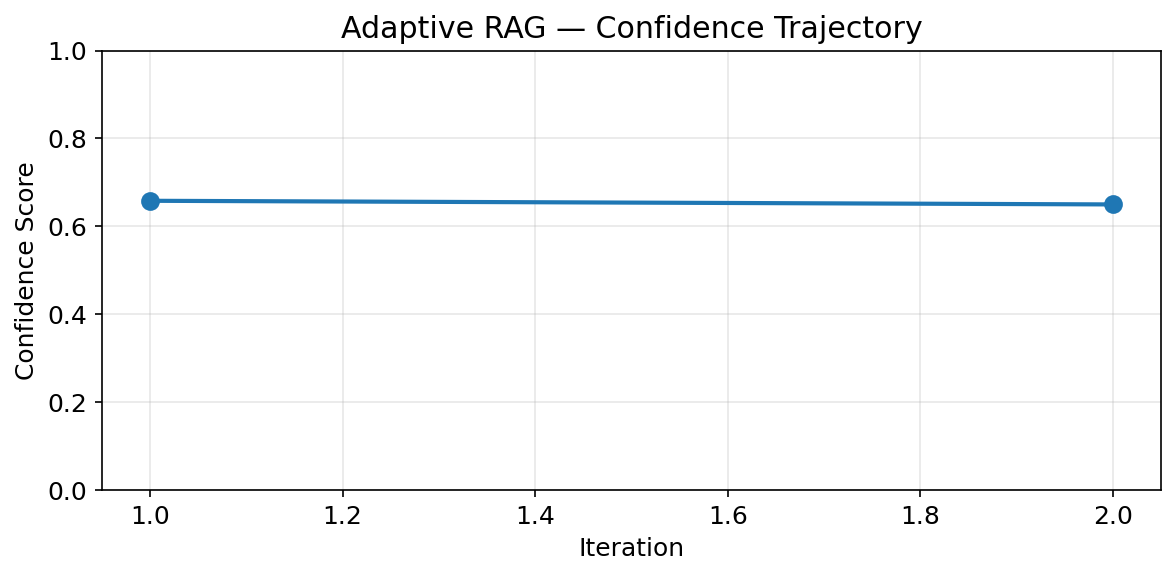

Saved: results/confidence_trajectory.png


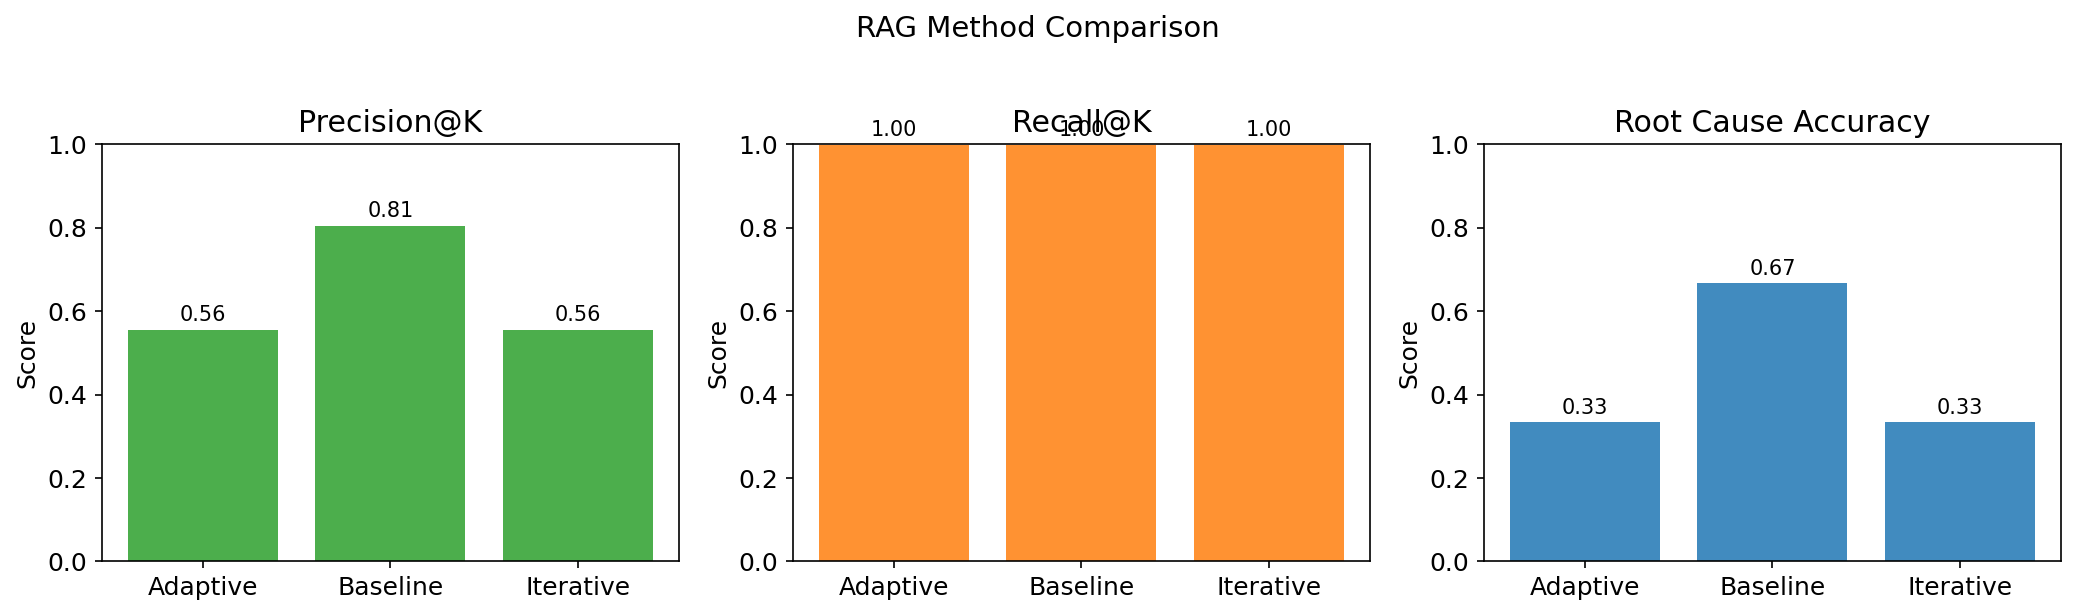

Saved: results/method_comparison.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12, "figure.dpi": 150})

results_dir = os.path.join(PROJECT_ROOT, "results")
os.makedirs(results_dir, exist_ok=True)

# ── Plot 1: Confidence Trajectory ──
fig, ax = plt.subplots(figsize=(8, 4))
trajectory = result["confidence_trajectory"]
ax.plot(range(1, len(trajectory) + 1), trajectory, "o-", color="#1f77b4", linewidth=2, markersize=8)
ax.set_xlabel("Iteration")
ax.set_ylabel("Confidence Score")
ax.set_title("Adaptive RAG — Confidence Trajectory")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(results_dir, "confidence_trajectory.png"))
plt.show()
print("Saved: results/confidence_trajectory.png")

# ── Plot 2: Method Comparison Bar Chart ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["Precision@K", "Recall@K", "Root Cause Accuracy"]
titles = ["Precision@K", "Recall@K", "Root Cause Accuracy"]
colors = ["#2ca02c", "#ff7f0e", "#1f77b4"]

methods = summary["Method"].tolist()
for ax, metric, title, color in zip(axes, metrics, titles, colors):
    vals = summary[metric].tolist()
    ax.bar(methods, vals, color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)

fig.suptitle("RAG Method Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(results_dir, "method_comparison.png"), bbox_inches="tight")
plt.show()
print("Saved: results/method_comparison.png")

## Step 12: Inspect Memory Store

The agent persists structured incidents so future queries benefit from past analyses.

In [19]:
if agent.memory:
    incidents = agent.memory.incidents
    print(f"Memory store contains {len(incidents)} incident(s):\n")
    for inc in incidents:
        print(f"  Query:      {inc.query}")
        print(f"  Root Cause: {inc.root_cause}")
        print(f"  Confidence: {inc.confidence:.4f}")
        print(f"  Timestamp:  {inc.timestamp}")
        print(f"  Logs:       {len(inc.supporting_logs)} entries")
        print()
else:
    print("Memory store is disabled.")

Memory store contains 4 incident(s):

  Query:      Why did UE4 get released? Trace the failure chain using timestamps across all files.
  Root Cause: UE4 was released due to a failure while applying an RRCReconfiguration message.
  Confidence: 0.6581
  Timestamp:  2026-04-17T21:08:33
  Logs:       12 entries

  Query:      Why did UE4 get released? Trace the failure chain.
  Root Cause: UE4 was released due to a failure while applying an RRCReconfiguration message.
  Confidence: 0.6572
  Timestamp:  2026-04-17T21:11:17
  Logs:       12 entries

  Query:      What caused PDSCH decode errors in log3?
  Root Cause: RRC releases on UE1 and UE4 were triggered due to a failure while applying an RRCReconfiguration message, resulting in a long forward jump of packet numbers.
  Confidence: 0.7836
  Timestamp:  2026-04-17T21:12:19
  Logs:       12 entries

  Query:      Why did the eGate console show bearer setup failure?
  Root Cause: Failure while applying RRCReconfiguration message to UE4 tr

## Step 13: Launch Streamlit Dashboard

Run the interactive dashboard for real-time telecom log analysis.

```bash
cd <project_root>
streamlit run streamlit_app.py
```

The dashboard provides three modes:
- **Adaptive Analysis** — Full adaptive iterative pipeline with live confidence tracking
- **Pass vs Fail** — Baseline vs Iterative comparison
- **Deep Debug** — Manual hybrid retrieval exploration